# Setup

The following cell sets up everything necessary to train the GCN.

In [ ]:
# Get contyent from drive
from google.colab import drive
drive.mount('/content/drive')

# Get GitHub token from Colab secrets
from google.colab import userdata
token = userdata.get('github_token')

# Clone the repo if it doesn't exist. If not then pull latest
import os
if not os.path.exists('/content/agnn'):
    !git clone https://{token}@github.com/charlottedavidson524/alzheimers-gnn.git /content/agnn
%cd /content/agnn
!git pull

# Install project. Need to do this after a fresh clone
!pip install -e . --quiet

# Copy data to local storage for faster access
if not os.path.exists("/content/graphs"):
    !cp -r /content/drive/MyDrive/alzheimers-gnn-data/graphs /content/graphs
if not os.path.exists("/content/participants.tsv"):
    !cp /content/drive/MyDrive/alzheimers-gnn-data/participants.tsv /content/participants.tsv

# Check that graphs, participants and results are all being stored where is expected
from agnn.paths import get_graphs_root, get_participants_tsv, get_results_root
print(f"Graphs: {get_graphs_root()}")
print(f"Participants: {get_participants_tsv()}")
print(f"Results: {get_results_root()}")

# GPU check
import torch
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Not available'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/agnn
Already up to date.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for agnn (pyproject.toml) ... done
Graphs: /content/graphs
Participants: /content/participants.tsv
Results: /content/drive/MyDrive/alzheimers-gnn-data/results
GPU: Tesla T4


Install torch geometric. Do it quietly so as not to clutter up notebook

In [ ]:
!pip install torch-geometric --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.8 MB/s eta 0:00:00


Test MultiBandGCN is configured correctly

In [ ]:
from torch_geometric.data import Data, Batch
from agnn.gnn.model import MultiBandGCN

# Create dummy delta and alpha2 graphs
delta = Data(x=torch.rand(125, 2), edge_index=torch.randint(0, 125, (2, 3100)), edge_attr=torch.rand(3100, 1), y=torch.tensor([1]))
alpha2 = Data(x=torch.rand(125, 2), edge_index=torch.randint(0, 125, (2, 3100)), edge_attr=torch.rand(3100, 1), y=torch.tensor([1]))

# Batch them. Simulate batch size 2.
delta_batch = Batch.from_data_list([delta, delta])
alpha2_batch = Batch.from_data_list([alpha2, alpha2])

# Instantiate and forward
model = MultiBandGCN()
logits = model(delta_batch, alpha2_batch)

print(f"Output shape: {logits.shape}")  # Should be (2, 2) if it worked properly
print(f"Sample logits: {logits}")

Output shape: torch.Size([2, 2])
Sample logits: tensor([[-0.1733, -0.2017],
        [-0.1623, -0.1534]], grad_fn=<AddmmBackward0>)


Test load_subject_graphs() and pair_by_epochs() functions are working properly using the first five skeleton subjects

In [ ]:
from agnn.paths import get_graphs_root
from agnn.gnn.data import load_subject_graphs, pair_by_epoch, make_cv_splits

# Load the first 5 subjects
subjects = ["sub-01", "sub-02", "sub-03", "sub-04", "sub-05"]
graphs = load_subject_graphs(subjects, get_graphs_root())
print(f"Total graphs: {len(graphs)}")

# Pair them
pairs = pair_by_epoch(graphs)
print(f"Total pairs: {len(pairs)}")
print(f"Labels: {set(p[2] for p in pairs)}")

Total graphs: 888
Total pairs: 444
Labels: {0}


Total graphs being 888 and total pairs being 444 looks correct.

Test that the collate_pairs function is working

In [ ]:
from torch.utils.data import DataLoader
from agnn.gnn.data import GraphPairDataset, collate_pairs

# Wrap the pairs list in a PyTorch Dataset so DataLoader can iterate over it
dataset = GraphPairDataset(pairs)
loader = DataLoader(dataset, batch_size=4, shuffle=False, collate_fn=collate_pairs)

# Get the first batch to check catching and collation is working properly.
delta_batch, alpha2_batch, labels = next(iter(loader))
print(f"Delta batch: {delta_batch}")
print(f"Alpha2 batch: {alpha2_batch}")
print(f"Labels: {labels}")
print(f"Labels shape: {labels.shape}")

Delta batch: DataBatch(x=[500, 2], edge_index=[2, 12400], edge_attr=[12400, 1], subject_id=[4], epoch_idx=[4], band=[4], y=[4], batch=[500], ptr=[5])
Alpha2 batch: DataBatch(x=[500, 2], edge_index=[2, 12400], edge_attr=[12400, 1], subject_id=[4], epoch_idx=[4], band=[4], y=[4], batch=[500], ptr=[5])
Labels: tensor([0, 0, 0, 0])
Labels shape: torch.Size([4])


Outputs are all looking as expected

Check that the model is consuming real batched data correctly.

In [ ]:
from agnn.gnn.model import MultiBandGCN

# Set model to eval mode and run it on the batched data
model = MultiBandGCN()
model.eval()

# This is a diagnostic forwrad pass so no gradient tracking needed
with torch.no_grad():
    logits = model(delta_batch, alpha2_batch)

print(f"Logits shape: {logits.shape}") # Should see output shape (4, 2) because it matches 4 samples x 2 classes
print(f"Sample logits: {logits}")

Logits shape: torch.Size([4, 2])
Sample logits: tensor([[-0.1623, -0.1091],
        [-0.1621, -0.1101],
        [-0.1624, -0.1086],
        [-0.1620, -0.1103]])


Test that the training code is working correctly

In [ ]:
import torch
from agnn.paths import get_graphs_root
from agnn.gnn.model import MultiBandGCN
from agnn.gnn.data import load_subject_graphs, pair_by_epoch, make_cv_splits, make_dataloader, verify_no_subject_leakage
from agnn.gnn.train import train_fold, set_seed

# Set seed and switch to cuda if its available
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Take a balanced sample. This one contains 15 subjects, 6 non carriers and 9 carriers
non_carriers = ["sub-01", "sub-02", "sub-03", "sub-04", "sub-05", "sub-06"]
carriers = ["sub-32", "sub-33", "sub-34", "sub-35", "sub-36", "sub-37", "sub-38", "sub-39", "sub-40"]
subjects = non_carriers + carriers

# Load graph .pt files for the sample and pair delta with alpha-2 by (subject, epoch)
graphs = load_subject_graphs(subjects, get_graphs_root())
pairs = pair_by_epoch(graphs)
n_pos = sum(p[2] for p in pairs)
print(f"Total pairs: {len(pairs)}, positive class: {n_pos}/{len(pairs)} = {n_pos/len(pairs):.2%}")

# Create CV splits. Chose fold 0 as a smoke test
splits = make_cv_splits(pairs, n_folds=3, seed=42)  # 3 folds so should be 5 subjects per fold
train_idx, val_idx = splits[0]

# Use the defensive function to check that no subject appears in train and val
verify_no_subject_leakage(pairs, train_idx, val_idx)

# Check fold has both classes
train_labels = [pairs[i][2] for i in train_idx]
val_labels = [pairs[i][2] for i in val_idx]
print(f"Train: {sum(train_labels)}/{len(train_labels)} positive")
print(f"Val: {sum(val_labels)}/{len(val_labels)} positive")

# Build the train and val loaders for the chosen fold
train_loader = make_dataloader(pairs, train_idx, batch_size=32, shuffle=True)
val_loader = make_dataloader(pairs, val_idx, batch_size=32, shuffle=False)

# Fresh model on the target device
model = MultiBandGCN().to(device)

# Set up a short training config for the purposes of running a smoke test
config = {"learning_rate": 0.001, "weight_decay": 0.0001, "epochs": 10, "patience": 20, "class_weights": [1.5, 1.0]}

# Train one fold end to end and report best validation AUC
result = train_fold(model, train_loader, val_loader, config, device, verbose=True)
print(f"\nBest AUC: {result['best_auc']:.4f} at epoch {result['best_epoch']}")

Total pairs: 1291, positive class: 757/1291 = 58.64%
Train: 489/844 positive
Val: 268/447 positive
Epoch   1/10: train_loss=0.6909, val_loss=0.7067, val_auc=0.5513
Epoch   2/10: train_loss=0.6831, val_loss=0.7049, val_auc=0.5513
Epoch   3/10: train_loss=0.6680, val_loss=0.7045, val_auc=0.5519
Epoch   4/10: train_loss=0.6458, val_loss=0.7146, val_auc=0.5520
Epoch   5/10: train_loss=0.6273, val_loss=0.7287, val_auc=0.5517
Epoch   6/10: train_loss=0.6223, val_loss=0.7464, val_auc=0.5522
Epoch   7/10: train_loss=0.6243, val_loss=0.7496, val_auc=0.5522
Epoch   8/10: train_loss=0.6252, val_loss=0.7598, val_auc=0.5525
Epoch   9/10: train_loss=0.6268, val_loss=0.7450, val_auc=0.5514
Epoch  10/10: train_loss=0.6232, val_loss=0.7560, val_auc=0.5524

Best AUC: 0.5525 at epoch 8


## Train the Model

In [ ]:
import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, confusion_matrix
from agnn.paths import get_graphs_root, get_results_root
from agnn.gnn.model import MultiBandGCN
from agnn.gnn.data import load_subject_graphs, pair_by_epoch, make_cv_splits, make_dataloader, verify_no_subject_leakage
from agnn.gnn.train import train_fold, set_seed

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cpu":
    print("WARNING: running on CPU. Training will be slow.")

Device: cuda


Set up configuration, ie define hyperparameters

In [ ]:
config = {
    # Model hyperparameters
    "hidden_channels": 64,
    "embedding_dim": 32,
    "mlp_hidden": 32,
    "dropout": 0.5,

    # Training hyperparameters
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "batch_size": 32,
    "epochs": 200,
    "patience": 20,
    "class_weights": [1.5, 1.0],  # non-carrier (minority) to carrier (majority)

    # Cross-validation
    "n_folds": 5,
    "seed": 42,
}

# Print the config to check everything is looking right
print("Config:")
for k, v in config.items():
    print(f"  {k}: {v}")

Config:
  hidden_channels: 64
  embedding_dim: 32
  mlp_hidden: 32
  dropout: 0.5
  learning_rate: 0.001
  weight_decay: 0.0001
  batch_size: 32
  epochs: 200
  patience: 20
  class_weights: [1.5, 1.0]
  n_folds: 5
  seed: 42


Load and pair all of the subjects

In [ ]:
# Find all subject folders in the graphs directory
graphs_root = get_graphs_root()
subjects = sorted([d.name for d in graphs_root.iterdir() if d.is_dir()])
print(f"Found {len(subjects)} subjects at {graphs_root}")

# Load and pair all the graphs
graphs = load_subject_graphs(subjects, graphs_root)
pairs = pair_by_epoch(graphs)

# Check the cohort summary
n_positive = sum(p[2] for p in pairs)
print(f"Total pairs: {len(pairs)}")
print(f"Positive class (carriers): {n_positive} ({n_positive/len(pairs):.1%})")
print(f"Negative class (non-carriers): {len(pairs)-n_positive} ({(len(pairs)-n_positive)/len(pairs):.1%})")

Found 77 subjects at /content/graphs
Total pairs: 6653
Positive class (carriers): 3956 (59.5%)
Negative class (non-carriers): 2697 (40.5%)


Create CV splits and results directory

In [ ]:
# Create CV splits (seed is needed to control split)
set_seed(config["seed"])
splits = make_cv_splits(pairs, n_folds=config["n_folds"], seed=config["seed"])
print(f"Created {len(splits)} folds")

# This code creates timestamped results directory in Drive. Useful to see whats happening when
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = get_results_root()/f"run_{timestamp}"
run_dir.mkdir(parents=True, exist_ok=True)
print(f"Results will save to: {run_dir}")

# Save config used for this run
with open(run_dir/"config.json", "w") as f:
    json.dump(config, f, indent=2)

Created 5 folds
Results will save to: /content/drive/MyDrive/alzheimers-gnn-data/results/run_20260803_220100


Run 5-fold CV

In [ ]:
# Create empty list to store fold results
fold_results = []

# This is the main CV loop. Each iteration trains and evaluates one fold end to end
for fold_idx, (train_idx, val_idx) in enumerate(splits):
    print(f"\n{'='*60}")
    print(f"Fold {fold_idx+1}/{config['n_folds']}")
    print(f"{'='*60}")

    # Use the defensive leakage check function created earlier to check for subject leakage
    verify_no_subject_leakage(pairs, train_idx, val_idx)

    # Report fold composition
    train_labels = [pairs[i][2] for i in train_idx]
    val_labels = [pairs[i][2] for i in val_idx]
    train_subjects = {pairs[i][0].subject_id for i in train_idx}
    val_subjects = {pairs[i][0].subject_id for i in val_idx}

    # For both train and validation datasets, record the number of pairs, subjects, and percentage of carriers
    print(f"Train: {len(train_idx)} pairs, {len(train_subjects)} subjects, {sum(train_labels)}/{len(train_labels)} positive ({sum(train_labels)/len(train_labels):.1%})")
    print(f"Val: {len(val_idx)} pairs, {len(val_subjects)} subjects, {sum(val_labels)}/{len(val_labels)} positive ({sum(val_labels)/len(val_labels):.1%})")

    # Fresh model per fold to ensure independent training
    set_seed(config["seed"]+fold_idx)  # different seed per fold, but reproducible

    # These values come from the config
    model = MultiBandGCN(hidden_channels=config["hidden_channels"], embedding_dim=config["embedding_dim"], mlp_hidden=config["mlp_hidden"],
                         dropout=config["dropout"]).to(device)

    # Create train and validation loaders
    train_loader = make_dataloader(pairs, train_idx, batch_size=config["batch_size"], shuffle=True)
    val_loader = make_dataloader(pairs, val_idx, batch_size=config["batch_size"], shuffle=False)

    # Create fold directory for outputs
    fold_dir = run_dir/f"fold_{fold_idx}"
    fold_dir.mkdir(exist_ok=True)

    # Train this fold
    result = train_fold(model=model, train_loader=train_loader, val_loader=val_loader, config=config, device=device, checkpoint_path=fold_dir/"best_model.pt",
        verbose=True)

    # Save the training history. This will be used to plot curves later on
    with open(fold_dir/"history.json", "w") as f:
        json.dump(result["history"], f, indent=2)

    # Save predictions at best epoch. This will be used later for downstream metrics
    np.savez(
        fold_dir/"predictions.npz",
        y_true=result["best_metrics"]["y_true"],
        y_prob=result["best_metrics"]["y_prob"],
    )

    # Save fold-level metrics summary
    y_true = result["best_metrics"]["y_true"]
    y_prob = result["best_metrics"]["y_prob"]
    y_pred = (y_prob > 0.5).astype(int)

    # Collect the metrics and metadata into a dictionary for this particular fold
    fold_summary = {
        "fold": fold_idx,
        "best_auc": result["best_auc"],
        "best_epoch": result["best_epoch"],
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "n_train": len(train_idx),
        "n_val": len(val_idx),
        "n_train_subjects": len(train_subjects),
        "n_val_subjects": len(val_subjects),
    }

    # Save the fold summary to disk. This allows for later analysis,
    with open(fold_dir/"metrics.json", "w") as f:
        json.dump(fold_summary, f, indent=2)

    # Append to the running list created at the beginning. This can be used later for cross-fold aggregation.
    fold_results.append(fold_summary)

    print(f"\nFold {fold_idx+1} complete: AUC = {result['best_auc']:.4f} at epoch {result['best_epoch']}")


Fold 1/5
Train: 5375 pairs, 62 subjects, 3025/5375 positive (56.3%)
Val: 1278 pairs, 15 subjects, 931/1278 positive (72.8%)
Epoch   1/200: train_loss=0.6880, val_loss=0.7199, val_auc=0.5208
Epoch   2/200: train_loss=0.6860, val_loss=0.7500, val_auc=0.5206
Epoch   3/200: train_loss=0.6852, val_loss=0.7582, val_auc=0.5205
Epoch   4/200: train_loss=0.6859, val_loss=0.7185, val_auc=0.5207
Epoch   5/200: train_loss=0.6844, val_loss=0.7504, val_auc=0.5206
Epoch   6/200: train_loss=0.6842, val_loss=0.7363, val_auc=0.5207
Epoch   7/200: train_loss=0.6834, val_loss=0.7321, val_auc=0.5208
Epoch   8/200: train_loss=0.6827, val_loss=0.7389, val_auc=0.5208
Epoch   9/200: train_loss=0.6825, val_loss=0.7190, val_auc=0.5209
Epoch  10/200: train_loss=0.6817, val_loss=0.7370, val_auc=0.5210
Epoch  11/200: train_loss=0.6829, val_loss=0.7465, val_auc=0.5209
Epoch  12/200: train_loss=0.6832, val_loss=0.7441, val_auc=0.5207
Epoch  13/200: train_loss=0.6828, val_loss=0.7446, val_auc=0.5207
Epoch  14/200: tr

Aggregate cross fold metrics

In [ ]:
# Build cross-fold summary df
summary_df = pd.DataFrame(fold_results)
summary_df.to_csv(run_dir/"cross_fold_metrics.csv", index=False)
print("Cross-fold metrics:")
print(summary_df.to_string(index=False))

# Create some overall statistics
mean_auc = summary_df["best_auc"].mean()
std_auc = summary_df["best_auc"].std()
mean_f1 = summary_df["f1"].mean()

# Create a printed summary
print(f"\n{'='*60}")
print(f"Cross-fold summary (n_folds={config['n_folds']})")
print(f"{'='*60}")
print(f"AUC: {mean_auc:.4f} +/- {std_auc:.4f}")
print(f"F1: {mean_f1:.4f} +/- {summary_df['f1'].std():.4f}")
print(f"Precision: {summary_df['precision'].mean():.4f} +/- {summary_df['precision'].std():.4f}")
print(f"Recall: {summary_df['recall'].mean():.4f} +/- {summary_df['recall'].std():.4f}")

# Save top-level summary
top_summary = {
    "config": config,
    "n_subjects": len(subjects),
    "n_pairs": len(pairs),
    "class_balance": {
        "positive": n_positive,
        "negative": len(pairs)-n_positive,
        "ratio_pos": n_positive/len(pairs),
    },
    "cross_fold_auc": {
        "mean": float(mean_auc),
        "std": float(std_auc),
        "per_fold": summary_df["best_auc"].tolist(),
    },
    "cross_fold_f1": {
        "mean": float(mean_f1),
        "std": float(summary_df["f1"].std()),
    },
}

# Write the top level summary to the disk in Drive so it can survive session end
with open(run_dir/"summary.json", "w") as f:
    json.dump(top_summary, f, indent=2)

print(f"\nAll results saved to: {run_dir}")

Cross-fold metrics:
 fold  best_auc  best_epoch  precision   recall       f1  n_train  n_val  n_train_subjects  n_val_subjects
    0  0.521190          27   0.768293 0.406015 0.531272     5375   1278                62              15
    1  0.468992           2   0.574661 0.437931 0.497065     5256   1397                61              16
    2  0.501424           2   0.570048 0.744949 0.645868     5337   1316                62              15
    3  0.683681          26   0.652542 0.431373 0.519393     5332   1321                62              15
    4  0.606654           2   0.489565 0.867488 0.625903     5312   1341                61              16

Cross-fold summary (n_folds=5)
AUC: 0.5564 +/- 0.0875
F1: 0.5639 +/- 0.0672
Precision: 0.6110 +/- 0.1051
Recall: 0.5776 +/- 0.2135

All results saved to: /content/drive/MyDrive/alzheimers-gnn-data/results/run_20260803_220100


Training curves plot

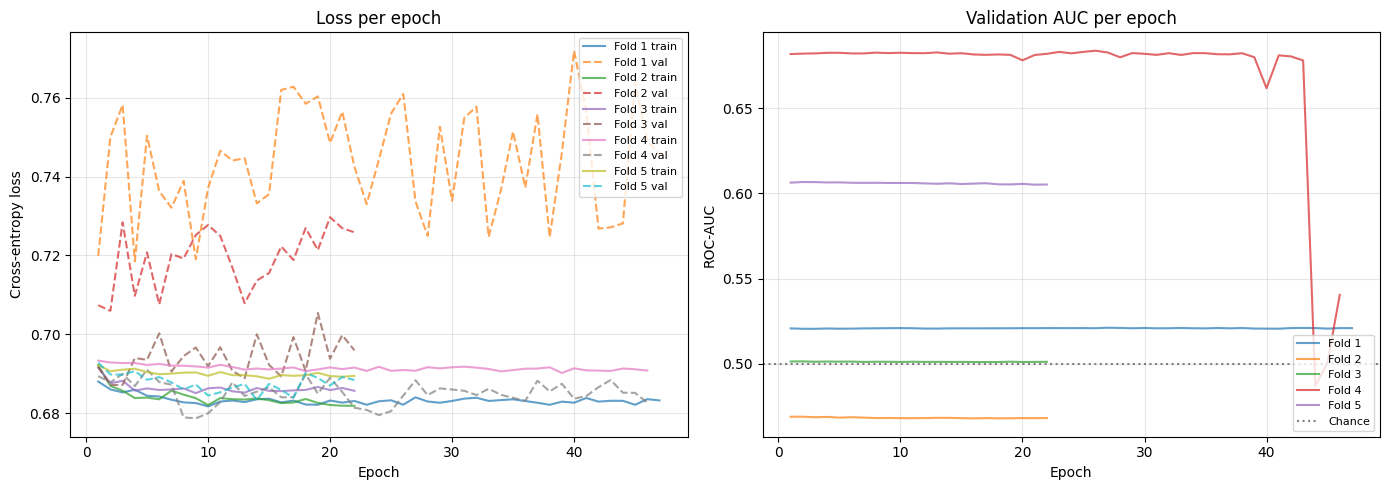

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Iterate over the folds. Log each fold's saved history and plot its curves.
for fold_idx in range(config["n_folds"]):
    fold_dir = run_dir/f"fold_{fold_idx}"
    with open(fold_dir/"history.json") as f:
        history = json.load(f)

    # Left axis will be train/validation loss curves. Right will be validation AUC
    epochs = range(1, len(history["train_loss"])+1)
    axes[0].plot(epochs, history["train_loss"], label=f"Fold {fold_idx+1} train", alpha=0.7)
    axes[0].plot(epochs, history["val_loss"], label=f"Fold {fold_idx+1} val", linestyle="--", alpha=0.7)
    axes[1].plot(epochs, history["val_auc"], label=f"Fold {fold_idx+1}", alpha=0.7)

# Title, labels, legend and grid for left hand graph
axes[0].set_title("Loss per epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend(fontsize=8, loc="upper right")
axes[0].grid(alpha=0.3)

# Title, labels, legend and grid for right hand graph
axes[1].set_title("Validation AUC per epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC-AUC")
axes[1].axhline(y=0.5, color="gray", linestyle=":", label="Chance")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].grid(alpha=0.3)

# Display and save the graphs
plt.tight_layout()
plt.savefig(run_dir/"training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

ROC curves plot

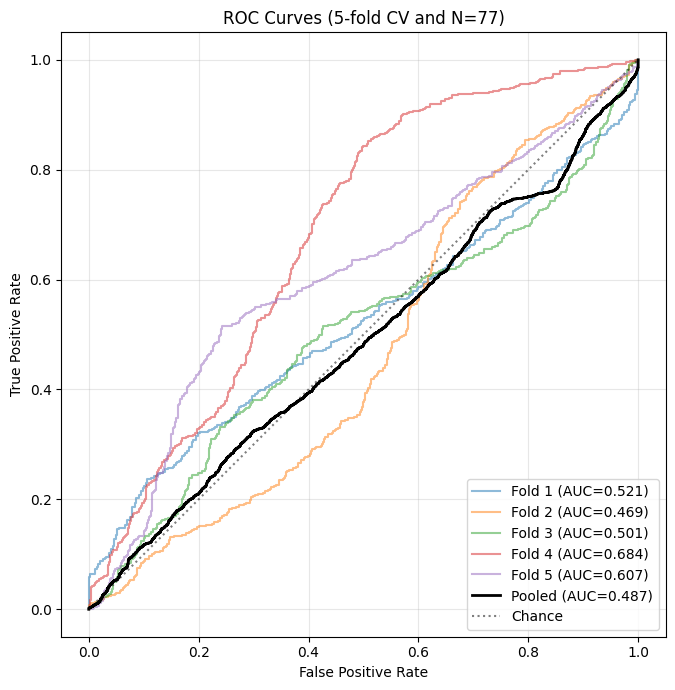

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

# Plot the ROC curve for each fold individually, this shows the variation between folds
for fold_idx in range(config["n_folds"]):
    fold_dir = run_dir/f"fold_{fold_idx}"
    preds = np.load(fold_dir/"predictions.npz")
    fpr, tpr, _ = roc_curve(preds["y_true"], preds["y_prob"])
    auc = roc_auc_score(preds["y_true"], preds["y_prob"])
    ax.plot(fpr, tpr, alpha=0.5, label=f"Fold {fold_idx + 1} (AUC={auc:.3f})")

# Prepare lists to collect predictions across folds for the pooled ROC
all_y_true = []
all_y_prob = []

# Load each fold's predictions and append to the running lsist
for fold_idx in range(config["n_folds"]):
    preds = np.load(run_dir/f"fold_{fold_idx}"/"predictions.npz")
    all_y_true.append(preds["y_true"])
    all_y_prob.append(preds["y_prob"])

# Flatten into single arrays covering the whole cohort
all_y_true = np.concatenate(all_y_true)
all_y_prob = np.concatenate(all_y_prob)

# Compute the pooled ROC and AUC across all folds combined
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
pooled_auc = roc_auc_score(all_y_true, all_y_prob)

# Draw the pooled ROC on top of the per-fold curves. This should give a cohort-level view
ax.plot(fpr, tpr, color="black", linewidth=2, label=f"Pooled (AUC={pooled_auc:.3f})")

# Chance line
ax.plot([0, 1], [0, 1], "k:", alpha=0.5, label="Chance")

# Title, labelss, legend and grid
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curves (5-fold CV and N={len(subjects)})")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
ax.set_aspect("equal")

# Display and save the graph
plt.tight_layout()
plt.savefig(run_dir/"roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Hyperparameter Tuning

Define the search space first

In [ ]:
search_space = {
    "learning_rate": [1e-4, 5e-4, 1e-3, 5e-3],
    "hidden_channels": [32, 64, 128],
    "dropout": [0.3, 0.5, 0.7],
}

Then run the tuning loop

In [ ]:
from itertools import product
from datetime import datetime

# Generate all combinations
configs = []
for lr, hc, do in product(
    search_space["learning_rate"],
    search_space["hidden_channels"],
    search_space["dropout"],
):
    configs.append({
        "learning_rate": lr,
        "hidden_channels": hc,
        "dropout": do,
    })

print(f"Total configs to try: {len(configs)}")

# Create tuning output directory
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
tune_dir = get_results_root()/f"tune_{timestamp}"
tune_dir.mkdir(parents=True, exist_ok=True)

# Run each config
tune_results = []
for cfg_idx, hp in enumerate(configs):
    print(f"\n{'='*60}")
    print(f"Config {cfg_idx+1}/{len(configs)}: lr={hp['learning_rate']}, hc={hp['hidden_channels']}, do={hp['dropout']}")
    print(f"{'='*60}")

    # Merge with base config
    full_config = {**config, **hp}

    # Run just 3 folds to save time during tuning
    # subset_splits = splits[:3]

    # Use folds 1, 2, and 4 — includes the highest-signal fold plus two chance-level folds
    subset_splits = [splits[0], splits[1], splits[3]]

    fold_aucs = []
    for fold_idx, (train_idx, val_idx) in enumerate(subset_splits):
        set_seed(config["seed"] + fold_idx)
        model = MultiBandGCN(
            hidden_channels=full_config["hidden_channels"],
            embedding_dim=full_config["embedding_dim"],
            mlp_hidden=full_config["mlp_hidden"],
            dropout=full_config["dropout"],
        ).to(device)

        train_loader = make_dataloader(pairs, train_idx, batch_size=full_config["batch_size"], shuffle=True)
        val_loader = make_dataloader(pairs, val_idx, batch_size=full_config["batch_size"], shuffle=False)

        result = train_fold(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            config=full_config,
            device=device,
            checkpoint_path=None,  # don't save during tuning
            verbose=False,  # suppress per-epoch prints
        )
        fold_aucs.append(result["best_auc"])

    mean_auc = sum(fold_aucs)/len(fold_aucs)
    print(f"Mean AUC (3-fold): {mean_auc:.4f}")

    tune_results.append({
        "config_idx": cfg_idx,
        "learning_rate": hp["learning_rate"],
        "hidden_channels": hp["hidden_channels"],
        "dropout": hp["dropout"],
        "mean_auc": mean_auc,
        "fold_aucs": fold_aucs,
    })

# Save tuning summary
tune_df = pd.DataFrame(tune_results)
tune_df = tune_df.sort_values("mean_auc", ascending=False)
tune_df.to_csv(tune_dir/"tuning_results.csv", index=False)
print(f"\nTuning complete. Best config:")
print(tune_df.head(5).to_string(index=False))

Total configs to try: 36

Config 1/36: lr=0.0001, hc=32, do=0.3
Mean AUC (3-fold): 0.5580

Config 2/36: lr=0.0001, hc=32, do=0.5
Mean AUC (3-fold): 0.5582

Config 3/36: lr=0.0001, hc=32, do=0.7
Mean AUC (3-fold): 0.5575

Config 4/36: lr=0.0001, hc=64, do=0.3
Mean AUC (3-fold): 0.5592

Config 5/36: lr=0.0001, hc=64, do=0.5
Mean AUC (3-fold): 0.5598

Config 6/36: lr=0.0001, hc=64, do=0.7
Mean AUC (3-fold): 0.5629

Config 7/36: lr=0.0001, hc=128, do=0.3
Mean AUC (3-fold): 0.5621

Config 8/36: lr=0.0001, hc=128, do=0.5
Mean AUC (3-fold): 0.5650

Config 9/36: lr=0.0001, hc=128, do=0.7
Mean AUC (3-fold): 0.5634

Config 10/36: lr=0.0005, hc=32, do=0.3
Mean AUC (3-fold): 0.5573

Config 11/36: lr=0.0005, hc=32, do=0.5
Mean AUC (3-fold): 0.5582

Config 12/36: lr=0.0005, hc=32, do=0.7
Mean AUC (3-fold): 0.5579

Config 13/36: lr=0.0005, hc=64, do=0.3
Mean AUC (3-fold): 0.5576

Config 14/36: lr=0.0005, hc=64, do=0.5
Mean AUC (3-fold): 0.5576

Config 15/36: lr=0.0005, hc=64, do=0.7
Mean AUC (3-fold)

Visualise the tuning results

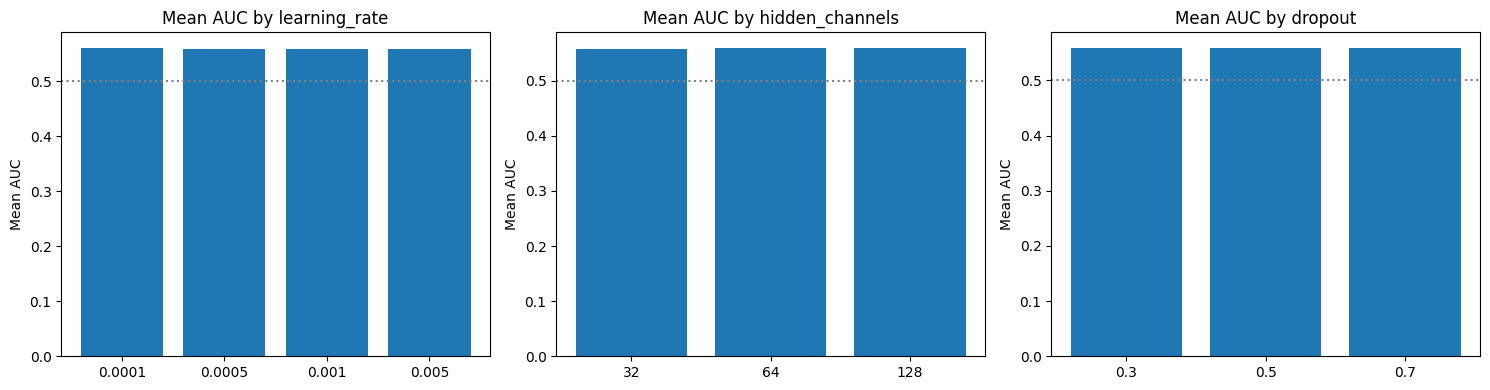

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, param in zip(axes, ["learning_rate", "hidden_channels", "dropout"]):
    grouped = tune_df.groupby(param)["mean_auc"].mean()
    ax.bar(range(len(grouped)), grouped.values)
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels([str(x) for x in grouped.index])
    ax.set_title(f"Mean AUC by {param}")
    ax.axhline(y=0.5, color="gray", linestyle=":", label="Chance")
    ax.set_ylabel("Mean AUC")

plt.tight_layout()
plt.savefig(tune_dir/"tuning_visualisation.png", dpi=150, bbox_inches="tight")
plt.show()